# 데이터 불러오기 및 결측치 처리

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import koreanize_matplotlib

In [30]:
raw = pd.read_csv('prj_data.csv')
raw.head()

,고객ID,나이,성별,거주지역,가입경로,멤버십등급,월평균구매금액,구매횟수,리뷰점수,쿠폰사용여부,메모,이탈여부
0,C0001,22.0,남,대구,앱,실버,62705.653045,7.0,3.3,N,재구매 유도 대상,1
1,C0002,58.0,여,부산,웹,VIP,180896.754122,18.0,4.7,Y,재구매 유도 대상,0
2,C0003,52.0,여,기타,앱,브론즈,30567.640969,3.0,3.3,Y,NaN,0
3,C0004,40.0,여,경기,앱,실버,71563.606370,3.0,3.8,N,재구매 유도 대상,0
4,C0005,40.0,남,경기,웹,골드,107967.380320,7.0,4.9,N,NaN,0


In [31]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   고객ID     500 non-null    str    
 1   나이       460 non-null    float64
 2   성별       485 non-null    str    
 3   거주지역     500 non-null    str    
 4   가입경로     480 non-null    str    
 5   멤버십등급    500 non-null    str    
 6   월평균구매금액  500 non-null    float64
 7   구매횟수     500 non-null    float64
 8   리뷰점수     475 non-null    float64
 9   쿠폰사용여부   500 non-null    str    
 10  메모       216 non-null    str    
 11  이탈여부     500 non-null    int64  
dtypes: float64(4), int64(1), str(7)
memory usage: 47.0 KB


In [32]:
raw.isnull().sum()

고객ID         0
나이          40
성별          15
거주지역         0
가입경로        20
멤버십등급        0
월평균구매금액      0
구매횟수         0
리뷰점수        25
쿠폰사용여부       0
메모         284
이탈여부         0
dtype: int64

In [33]:
missing_ratio = raw.isnull().mean()
missing_ratio

고객ID       0.000
나이         0.080
성별         0.030
거주지역       0.000
가입경로       0.040
멤버십등급      0.000
월평균구매금액    0.000
구매횟수       0.000
리뷰점수       0.050
쿠폰사용여부     0.000
메모         0.568
이탈여부       0.000
dtype: float64

In [38]:
drop_cols = missing_ratio[missing_ratio > 0.5].index.tolist()
df = raw.drop(columns=raw[drop_cols])
df.head()

,고객ID,나이,성별,거주지역,가입경로,멤버십등급,월평균구매금액,구매횟수,리뷰점수,쿠폰사용여부,이탈여부
0,C0001,22.0,남,대구,앱,실버,62705.653045,7.0,3.3,N,1
1,C0002,58.0,여,부산,웹,VIP,180896.754122,18.0,4.7,Y,0
2,C0003,52.0,여,기타,앱,브론즈,30567.640969,3.0,3.3,Y,0
3,C0004,40.0,여,경기,앱,실버,71563.606370,3.0,3.8,N,0
4,C0005,40.0,남,경기,웹,골드,107967.380320,7.0,4.9,N,0


In [39]:
num_cols = df.select_dtypes(include='number').columns
num_cols_na = num_cols[df[num_cols].isna().any()]

cat_cols = df.select_dtypes(exclude='number').columns
cat_cols_na = cat_cols[df[cat_cols].isna().any()]
num_cols_na, cat_cols_na

(Index(['나이', '리뷰점수'], dtype='str'), Index(['성별', '가입경로'], dtype='str'))

In [40]:
for c in num_cols_na:
    df[c] = df[c].fillna(df[c].mean())

for c in cat_cols_na:
    df[c] = df[c].fillna(df[c].mode()[0])

In [41]:
df.isnull().sum()

고객ID       0
나이         0
성별         0
거주지역       0
가입경로       0
멤버십등급      0
월평균구매금액    0
구매횟수       0
리뷰점수       0
쿠폰사용여부     0
이탈여부       0
dtype: int64

# 이상치 탐지 및 처리

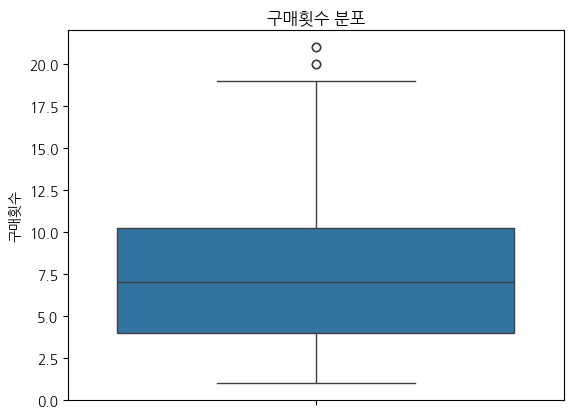

In [47]:
sns.boxplot(data=df['구매횟수'])
plt.title('구매횟수 분포')
plt.show()

In [51]:
q1 = df['구매횟수'].quantile(.25)
q3 = df['구매횟수'].quantile(.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(f'하한: {lower:.2f} / 상한: {upper:.2f}')

하한: -5.38 / 상한: 19.62


In [55]:
df['구매횟수'].describe()

count    500.000000
mean       7.822000
std        4.481795
min        1.000000
25%        4.000000
50%        7.000000
75%       10.250000
max       21.000000
Name: 구매횟수, dtype: float64

In [ ]:
# 경계값 대체
#   - 아예 말이 안 되는 값이 아니면서, 기존 최대값과 상한의 차이가 적기 때문
df['구매횟수'] = df['구매횟수'].clip(lower, upper)
df['구매횟수'].describe()

count    500.000000
mean       7.815000
std        4.462368
min        1.000000
25%        4.000000
50%        7.000000
75%       10.250000
max       19.625000
Name: 구매횟수, dtype: float64

# 범주형 변수 인코딩

In [62]:
cat_cols

Index(['고객ID', '성별', '거주지역', '가입경로', '멤버십등급', '쿠폰사용여부'], dtype='str')

In [77]:
# 원핫 인코딩
#   - 모두 순서 의미 없는 범주이기 때문
df_model = pd.get_dummies(data=df, columns=['성별', '거주지역', '가입경로', '쿠폰사용여부'])
df_model.head()

,고객ID,나이,멤버십등급,월평균구매금액,구매횟수,리뷰점수,이탈여부,성별_남,성별_여,거주지역_경기,거주지역_기타,거주지역_대구,거주지역_부산,거주지역_서울,가입경로_광고,가입경로_앱,가입경로_웹,가입경로_지인추천,쿠폰사용여부_N,쿠폰사용여부_Y
0,C0001,22.0,실버,62705.653045,7.0,3.3,1,True,False,False,False,True,False,False,False,True,False,False,True,False
1,C0002,58.0,VIP,180896.754122,18.0,4.7,0,False,True,False,False,False,True,False,False,False,True,False,False,True
2,C0003,52.0,브론즈,30567.640969,3.0,3.3,0,False,True,False,True,False,False,False,False,True,False,False,False,True
3,C0004,40.0,실버,71563.606370,3.0,3.8,0,False,True,True,False,False,False,False,False,True,False,False,True,False
4,C0005,40.0,골드,107967.380320,7.0,4.9,0,True,False,True,False,False,False,False,False,False,True,False,True,False


In [78]:
print('==== 인코딩 전 ====')
print(f'데이터프레임 형태: {df.shape}\n컬럼 목록: {df.columns.tolist()}')

print('\n==== 인코딩 후 ====')
print(f'데이터프레임 형태: {df_model.shape}\n컬럼 목록: {df_model.columns.tolist()}')

==== 인코딩 전 ====
데이터프레임 형태: (500, 11)
컬럼 목록: ['고객ID', '나이', '성별', '거주지역', '가입경로', '멤버십등급', '월평균구매금액', '구매횟수', '리뷰점수', '쿠폰사용여부', '이탈여부']

==== 인코딩 후 ====
데이터프레임 형태: (500, 20)
컬럼 목록: ['고객ID', '나이', '멤버십등급', '월평균구매금액', '구매횟수', '리뷰점수', '이탈여부', '성별_남', '성별_여', '거주지역_경기', '거주지역_기타', '거주지역_대구', '거주지역_부산', '거주지역_서울', '가입경로_광고', '가입경로_앱', '가입경로_웹', '가입경로_지인추천', '쿠폰사용여부_N', '쿠폰사용여부_Y']


# 파생변수 생성 및 스케일링

In [81]:
df_model['1회당평균구매금액'] = df_model['월평균구매금액'] / df_model['구매횟수']
df_model.head()

,고객ID,나이,멤버십등급,월평균구매금액,구매횟수,리뷰점수,이탈여부,성별_남,성별_여,거주지역_경기,거주지역_기타,거주지역_대구,거주지역_부산,거주지역_서울,가입경로_광고,가입경로_앱,가입경로_웹,가입경로_지인추천,쿠폰사용여부_N,쿠폰사용여부_Y,1회당평균구매금액
0,C0001,22.0,실버,62705.653045,7.0,3.3,1,True,False,False,False,True,False,False,False,True,False,False,True,False,8957.950435
1,C0002,58.0,VIP,180896.754122,18.0,4.7,0,False,True,False,False,False,True,False,False,False,True,False,False,True,10049.819673
2,C0003,52.0,브론즈,30567.640969,3.0,3.3,0,False,True,False,True,False,False,False,False,True,False,False,False,True,10189.213656
3,C0004,40.0,실버,71563.606370,3.0,3.8,0,False,True,True,False,False,False,False,False,True,False,False,True,False,23854.535457
4,C0005,40.0,골드,107967.380320,7.0,4.9,0,True,False,True,False,False,False,False,False,False,True,False,True,False,15423.911474


In [95]:
scale_cols = df_model.select_dtypes(include='number').columns.difference(['이탈여부'])
df_model[scale_cols].describe().loc[['mean', 'std']]

,1회당평균구매금액,구매횟수,나이,리뷰점수,월평균구매금액
mean,14988.552727,7.815000,43.195652,3.736632,97684.003413
std,20192.362254,4.462368,14.384666,0.540323,106309.940848


In [96]:
scaler = StandardScaler()
df_model[scale_cols] = scaler.fit_transform(df_model[scale_cols])
df_model[scale_cols].describe().loc[['mean', 'std']]

,1회당평균구매금액,구매횟수,나이,리뷰점수,월평균구매금액
mean,7.105427e-17,-1.261213e-16,2.984279e-16,1.669775e-16,6.394885e-17
std,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00


In [97]:
df_model.to_csv('prj_data_cleaned.csv', index=False)